# Data Mining Lab 2
## Өгөгдлийн шинж чанар: Тайлбарлалт, Дүрслэл ба Төсөөлөл
**Dataset:** StudentsPerformance.csv

**Зорилго:**  
Энэхүү лабораторийн ажлыг дуусгасны дараа оюутан:
- Өгөгдлийн объект, аттрибутын тухай ойлголтыг бодит dataset дээр ашиглаж сурна  
- Статистик тайлбарлалтын аргуудыг (төв хандлага, хэлбэлзэл, тархалтын хэлбэр) тооцоолж чадна  
- Өгөгдлийг график аргаар зөв дүрслэнэ  
- Өгөгдлийн объектуудын хоорондын төсөө (similarity) ба ялгааг (dissimilarity) хэмжинэ  
- Нормализацийн аргуудыг (Min-Max, Z-score) ойлгож, хэрэглэнэ  



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## 0) Dataset унших

**StudentsPerformance.csv** файлыг ашиглана.



In [2]:
df = pd.read_csv("StudentsPerformance_M4YygK2.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 1) Өгөгдлийн объект ба аттрибут (Data Object & Attribute)

- Dataset дахь **мөр бүр** нэг өгөгдлийн объект (нэг оюутан) юм: x=(a₁, a₂, …, aₙ)  
- Dataset дахь **багана бүр** нэг аттрибут (feature)  

### 1.1 Dataset-ийн бүтэц
- Хэдэн объект (мөр), хэдэн аттрибут (багана) вэ?  
- Аль аттрибут numeric, аль нь categorical вэ?



In [3]:
print("Shape (objects, attributes):", df.shape)
print("Attributes:", list(df.columns))
df.dtypes


Shape (objects, attributes): (1000, 8)
Attributes: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

### 1.2 Missing болон duplicate шалгах

- Аль аттрибутад missing value байна вэ?  
- Давхардсан объект (мөр) байгаа эсэх?



In [4]:
# Missing values
df.isna().sum()


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [5]:
# Duplicate rows
df.duplicated().sum()


np.int64(0)

### 1.3 Numeric ба Categorical аттрибутууд



In [6]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

print("Numeric columns:", list(num_cols))
print("Categorical columns:", list(cat_cols))


Numeric columns: ['math score', 'reading score', 'writing score']
Categorical columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


### TASK A: Аттрибутын хэмжээсийн түвшин (Measurement Level)

Лекцийн дагуу (**Nominal, Ordinal, Interval, Ratio**) доорх аттрибут бүрийг ангилж, шалтгаанаа бичнэ үү:

| Аттрибут | Төрөл (Nominal/Ordinal/Interval/Ratio) | Шалтгаан |
|---|---|---|
| gender | | |
| race/ethnicity | | |
| parental level of education | | |
| lunch | | |
| test preparation course | | |
| math score | | |
| reading score | | |
| writing score | | |

**Санамж:** score-ууд нь 0 цэгтэй (0 оноо = мэдлэггүй гэсэн үг биш ч бодит тоон утга) тул ихэвчлэн ratio гэж авч үздэг, харин `parental level of education` дараалалтай тул ordinal.



In [7]:
levels = pd.DataFrame({
    "Аттрибут": ["gender", "race/ethnicity", "parental level of education", "lunch",
                 "test preparation course", "math score", "reading score", "writing score"],
    "Төрөл": ["Nominal", "Nominal", "Ordinal", "Nominal", "Nominal", "Ratio", "Ratio", "Ratio"],
})
levels["Утгууд"] = [f"{df[c].min()} – {df[c].max()}" if c in num_cols else ", ".join(df[c].unique())
                    for c in levels["Аттрибут"]]
levels

,Аттрибут,Төрөл,Утгууд
0,gender,Nominal,"female, male"
1,race/ethnicity,Nominal,"group B, group C, group A, group D, group E"
2,parental level of education,Ordinal,"bachelor's degree, some college, master's degr..."
3,lunch,Nominal,"standard, free/reduced"
4,test preparation course,Nominal,"none, completed"
5,math score,Ratio,0 – 100
6,reading score,Ratio,17 – 100
7,writing score,Ratio,10 – 100


**TASK A хариулт:**

| Аттрибут | Төрөл | Шалтгаан |
|---|---|---|
| gender | Nominal | female/male гэсэн нэр, дараалалгүй |
| race/ethnicity | Nominal | group A–E зөвхөн бүлгийн нэр, A < B гэсэн утга байхгүй |
| parental level of education | Ordinal | some high school < high school < … < master's гэж эрэмбэлж болно, гэхдээ зай нь тэнцүү биш |
| lunch | Nominal | standard / free/reduced, дараалалгүй |
| test preparation course | Nominal | none / completed, хоёр утгатай (binary) |
| math score | Ratio | 0–100 тоо, 0 цэг тодорхой, 80 нь 40-ийн 2 дахин гэж хэлж болно |
| reading score | Ratio | мөн адил |
| writing score | Ratio | мөн адил |

## 2) Статистик тайлбарлалт (Statistical Description)

### 2.1 Ерөнхий статистик



In [8]:
df.describe()


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### 2.2 Төв хандлага: Mean, Median, Mode

- **Mean** — бүх утгыг ашигладаг ч outlier-д мэдрэмтгий  
- **Median** — эрэмбэлсэн дундах утга, outlier-д тэсвэртэй  
- **Mode** — хамгийн олон давтагдсан утга



In [9]:
for col in num_cols:
    print(f"{col:15s} mean={df[col].mean():.2f}  median={df[col].median():.2f}  mode={df[col].mode()[0]}")


math score      mean=66.09  median=66.00  mode=65
reading score   mean=69.17  median=70.00  mode=72
writing score   mean=68.05  median=69.00  mode=74


### 2.3 Хэлбэлзэл: Variance, Std



In [10]:
for col in num_cols:
    print(f"{col:15s} variance={df[col].var():.2f}  std={df[col].std():.2f}")


math score      variance=229.92  std=15.16
reading score   variance=213.17  std=14.60
writing score   variance=230.91  std=15.20


### 2.4 Тархалтын хэлбэр (Distribution Shape)

Лекц ёсоор:
- Symmetric: Mean ≈ Median ≈ Mode  
- Left-skewed: Mean < Median < Mode  
- Right-skewed: Mode < Median < Mean

Доорх код Mean ба Median-ийг харьцуулж, тархалтын хэлбэрийг тодорхойлно.



In [11]:
for col in num_cols:
    m, med = df[col].mean(), df[col].median()
    if abs(m - med) < 0.5:
        shape = "Symmetric"
    elif m < med:
        shape = "Left-skewed"
    else:
        shape = "Right-skewed"
    print(f"{col:15s} mean={m:.2f} median={med:.2f} -> {shape}")


math score      mean=66.09 median=66.00 -> Symmetric
reading score   mean=69.17 median=70.00 -> Left-skewed
writing score   mean=68.05 median=69.00 -> Left-skewed


## 3) Graphик дүрслэл (Visualization)

Лекцэд дурдсанчлан аттрибутын төрлөөс хамааран график сонгоно:

| Өгөгдөл | График |
|---|---|
| Categorical | Bar, Pie |
| Numerical | Histogram, Boxplot |
| Relationship | Scatter |



### 3.1 Bar chart – Categorical аттрибут (race/ethnicity)


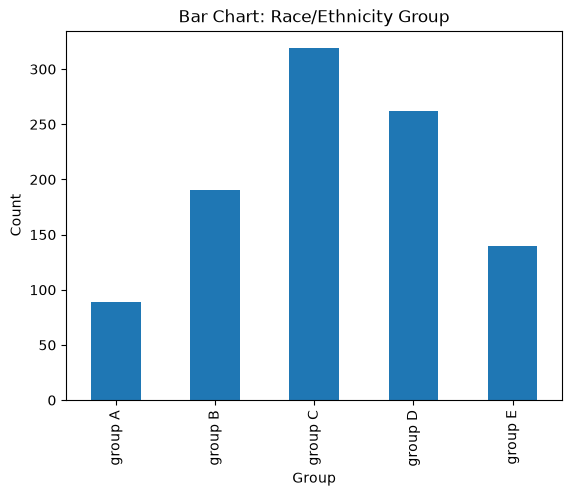

In [12]:
plt.figure()
df['race/ethnicity'].value_counts().sort_index().plot(kind='bar')
plt.title("Bar Chart: Race/Ethnicity Group")
plt.xlabel("Group")
plt.ylabel("Count")
plt.show()


### 3.2 Histogram – Reading score


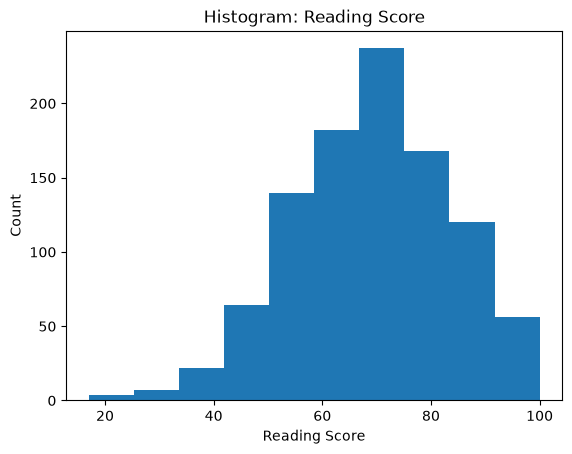

In [13]:
plt.figure()
plt.hist(df['reading score'], bins=10)
plt.title("Histogram: Reading Score")
plt.xlabel("Reading Score")
plt.ylabel("Count")
plt.show()


### 3.3 Boxplot – Test preparation course vs Writing score


<Figure size 640x480 with 0 Axes>

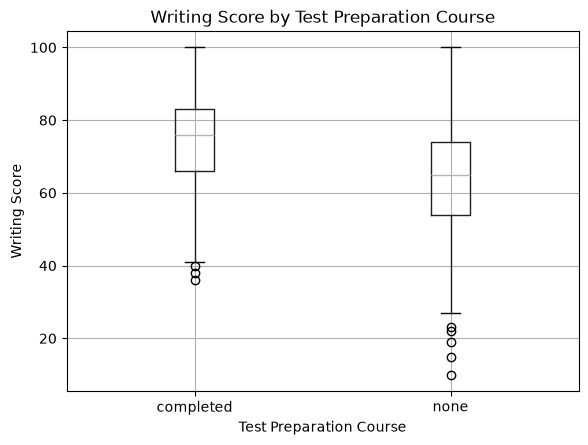

In [14]:
plt.figure()
df.boxplot(column='writing score', by='test preparation course')
plt.title("Writing Score by Test Preparation Course")
plt.suptitle("")
plt.xlabel("Test Preparation Course")
plt.ylabel("Writing Score")
plt.show()


### 3.4 Scatter – Reading vs Writing score


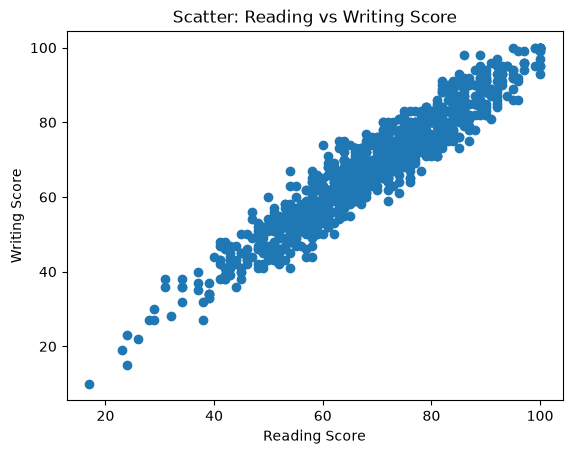

In [15]:
plt.figure()
plt.scatter(df['reading score'], df['writing score'])
plt.title("Scatter: Reading vs Writing Score")
plt.xlabel("Reading Score")
plt.ylabel("Writing Score")
plt.show()


## 4) Төсөө ба ялгаа (Similarity & Dissimilarity)

- **Euclidean distance:** d(x,y) = sqrt(Σ(xᵢ - yᵢ)²)  
- **Manhattan distance:** d(x,y) = Σ|xᵢ - yᵢ|  

Доорх жишээнд эхний 3 оюутны (`math score`, `reading score`, `writing score`) утгуудыг ашиглан хос бүрийн зайг тооцооно.



In [16]:
from itertools import combinations

sample = df.loc[0:2, ['math score', 'reading score', 'writing score']]
sample.index = ['A', 'B', 'C']
sample


,math score,reading score,writing score
A,72,72,74
B,69,90,88
C,90,95,93


In [17]:
def euclidean(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def manhattan(a, b):
    return np.sum(np.abs(a - b))

for i, j in combinations(sample.index, 2):
    a, b = sample.loc[i].values, sample.loc[j].values
    print(f"{i}-{j}:  Euclidean={euclidean(a, b):.2f}   Manhattan={manhattan(a, b):.2f}")


A-B:  Euclidean=23.00   Manhattan=35.00
A-C:  Euclidean=34.84   Manhattan=60.00
B-C:  Euclidean=22.16   Manhattan=31.00


### TASK B: Хамгийн төстэй оюутнууд

1. Дээрх гурван оюутны аль хос нь хамгийн бага Euclidean distance-той, өөрөөр хэлбэл хамгийн **төстэй** вэ?  
2. Manhattan distance-аар бодоход хариулт өөрчлөгдөж байна уу?  
3. Өөрийн сонгосон 3 өөр оюутнаар дахин тооцоолж, дүгнэлт хий.



In [18]:
# 1-2. Эхний 3 оюутан: хамгийн бага зайтай хос
dist = pd.DataFrame(
    [(i, j, euclidean(sample.loc[i].values, sample.loc[j].values), manhattan(sample.loc[i].values, sample.loc[j].values))
     for i, j in combinations(sample.index, 2)],
    columns=["pair_1", "pair_2", "euclidean", "manhattan"],
)
print(dist.round(2))
print("Хамгийн төстэй (Euclidean):", dist.loc[dist.euclidean.idxmin(), ["pair_1", "pair_2"]].tolist())
print("Хамгийн төстэй (Manhattan):", dist.loc[dist.manhattan.idxmin(), ["pair_1", "pair_2"]].tolist())

# 3. Өөр 3 оюутан (index 10, 20, 30)
my_sample = df.loc[[10, 20, 30], ['math score', 'reading score', 'writing score']]
display(my_sample)
for i, j in combinations(my_sample.index, 2):
    a, b = my_sample.loc[i].values, my_sample.loc[j].values
    print(f"{i}-{j}:  Euclidean={euclidean(a, b):.2f}   Manhattan={manhattan(a, b):.2f}")

  pair_1 pair_2  euclidean  manhattan
0      A      B      23.00         35
1      A      C      34.84         60
2      B      C      22.16         31
Хамгийн төстэй (Euclidean): ['B', 'C']
Хамгийн төстэй (Manhattan): ['B', 'C']


,math score,reading score,writing score
10,58,54,52
20,66,69,63
30,69,74,74


10-20:  Euclidean=20.25   Manhattan=34.00
10-30:  Euclidean=31.70   Manhattan=53.00
20-30:  Euclidean=12.45   Manhattan=19.00


**TASK B хариулт:**
1. **B–C** хос хамгийн төстэй: Euclidean = 22.16 (A–B = 23.00, A–C = 34.84).
2. Manhattan-аар ч **B–C** (31) хамгийн бага, хариулт өөрчлөгдөхгүй. Гэхдээ A–B (23.0) ба B–C (22.16) Euclidean дээр маш ойрхон байсан бол Manhattan дээр 35 vs 31 болж ялгаа нь томорсон.
3. 10, 20, 30-р оюутнуудаар: **20–30** хамгийн төстэй (Euclidean 12.45, Manhattan 19), 10–30 хамгийн хол (31.70 / 53). Хоёр хэмжүүр ижил эрэмбэ гаргаж байна. Оноо бүх хичээлд ижил чиглэлд зөрж байвал хоёр зай ижил дүгнэлт өгдөг.

## 5) Нормализаци (Normalization)

Яагаад хэрэгтэй вэ? Өөр өөр масштабтай аттрибутууд distance тооцооллыг гуйвуулахаас сэргийлнэ.

- **Min-Max normalization:** x' = (x - min) / (max - min)  
- **Z-score normalization:** x' = (x - mean) / std



In [19]:
scores = df[['math score', 'reading score', 'writing score']]

minmax = (scores - scores.min()) / (scores.max() - scores.min())
zscore = (scores - scores.mean()) / scores.std()

print("Min-Max normalized (эхний 5):")
display(minmax.head())
print("\nZ-score normalized (эхний 5):")
display(zscore.head())


Min-Max normalized (эхний 5):


,math score,reading score,writing score
0,0.72,0.662651,0.711111
1,0.69,0.879518,0.866667
2,0.90,0.939759,0.922222
3,0.47,0.481928,0.377778
4,0.76,0.734940,0.722222



Z-score normalized (эхний 5):


,math score,reading score,writing score
0,0.389828,0.193902,0.391296
1,0.191979,1.426762,1.312612
2,1.576922,1.769223,1.641653
3,-1.258913,-0.833482,-1.582952
4,0.653627,0.604855,0.457104


### TASK C: Нормализацийн нөлөө

1. Min-Max normalize хийсэн эхний 3 оюутны хооронд Euclidean distance-ийг дахин тооцоол.  
2. Normalize хийхээс өмнөх distance-тай харьцуулж, ялгааг тайлбарла (үгээр).  
3. Аль тохиолдолд normalization хийх нь **зайлшгүй шаардлагатай** вэ? (жишээ өг)



In [20]:
mm_sample = minmax.loc[0:2]
mm_sample.index = ['A', 'B', 'C']

rows = []
for i, j in combinations(sample.index, 2):
    rows.append({
        "pair": f"{i}-{j}",
        "raw_euclidean": euclidean(sample.loc[i].values, sample.loc[j].values),
        "minmax_euclidean": euclidean(mm_sample.loc[i].values, mm_sample.loc[j].values),
    })
pd.DataFrame(rows).round(4)

,pair,raw_euclidean,minmax_euclidean
0,A-B,23.0000,0.2686
1,A-C,34.8425,0.3921
2,B-C,22.1585,0.2254


**TASK C хариулт:**
1. Min-Max дараах Euclidean: A–B = 0.2686, A–C = 0.3921, B–C = 0.2254.
2. Тоон утга нь 0–1 хуваарь руу орсон тул их жижгэрсэн, гэхдээ эрэмбэ нь өөрчлөгдөөгүй (B–C < A–B < A–C). Учир нь 3 score бүгд 0–100 хуваарьтай. Min нь өөр (math 0, reading 17, writing 10) учраас reading-ийн ялгаа бага зэрэг илүү жинтэй болсон.
3. Аттрибутуудын хэмжээ маш өөр үед зайлшгүй хэрэгтэй. Жишээ: оюутныг `нас` (18–25) ба `сарын орлого` (500,000–3,000,000₮)-оор харьцуулбал Euclidean бараг зөвхөн орлогоос хамаарна. Normalize хийсний дараа хоёулаа тэнцүү нөлөөлнө (kNN, k-means зэрэгт).

## TASK D: Feature Analysis

Доорх асуултуудад **Python код бичиж** хариулна уу.

1. Аль categorical feature (`gender`, `lunch`, `test preparation course`) нь math score-т хамгийн их ялгаа үүсгэж байна вэ?  
2. Тухайн feature бүрээр math score-ийн **дундаж**-ийг тооцоол (`groupby()` + `mean()`).  
3. Гурван score-ийн дундаас аль нь хамгийн их **variance**-тай вэ, энэ нь юуг илэрхийлж болох вэ?



In [21]:
# 1-2. Categorical feature бүрээр math score-ийн дундаж
gaps = {}
for col in ['gender', 'lunch', 'test preparation course']:
    means = df.groupby(col)['math score'].mean()
    gaps[col] = means.max() - means.min()
    print(means.round(2).to_string(), "\n  ялгаа:", round(gaps[col], 2), "\n")

print("Хамгийн их ялгаа үүсгэдэг feature:", max(gaps, key=gaps.get))

# 3. Аль score хамгийн их variance-тай вэ
var = df[['math score', 'reading score', 'writing score']].var()
print("\n", var.round(2).to_string())
print("Хамгийн их variance:", var.idxmax())

gender
female    63.63
male      68.73 
  ялгаа: 5.1 

lunch
free/reduced    58.92
standard        70.03 
  ялгаа: 11.11 

test preparation course
completed    69.70
none         64.08 
  ялгаа: 5.62 

Хамгийн их ялгаа үүсгэдэг feature: lunch

 math score       229.92
reading score    213.17
writing score    230.91
Хамгийн их variance: writing score


**TASK D хариулт:**
1. **lunch** хамгийн их ялгаа үүсгэж байна: standard 70.03, free/reduced 58.92 → **11.11** оноо.
2. gender: male 68.73, female 63.63 (5.10). test preparation course: completed 69.70, none 64.08 (5.62).
3. **writing score** хамгийн их variance-тай (230.91), math бараг адил (229.92), reading хамгийн бага (213.17). Бичлэг, математикт оюутнуудын түвшин илүү ялгаатай, reading-т арай жигд байна гэсэн үг.

# Data Mining Lab 2 Тайлан
## Өгөгдлийн шинж чанар: Тайлбарлалт, Дүрслэл ба Төсөөлөл

**Нэр:** Enkhtur Erkhes  
**Оюутны код:** s22c067b  
**Анги / Бүлэг:** KU-5  
**Огноо:** 2026/09/28  

---

## 1. Dataset-ийн ерөнхий мэдээлэл
- Объектын (мөр) тоо: 1000
- Аттрибутын (багана) тоо: 8
- Numeric аттрибутууд: `math score`, `reading score`, `writing score`
- Categorical аттрибутууд: `gender`, `race/ethnicity`, `parental level of education`, `lunch`, `test preparation course`
- Missing value, duplicate мөр байхгүй.

---

## 2. Аттрибутын хэмжээсийн түвшин
- Nominal: gender, race/ethnicity, lunch, test preparation course
- Ordinal: parental level of education
- Ratio: math, reading, writing score

---

## 3. Статистик тайлбарлалт
- Mean, Median, Mode: math 66.09 / 66 / 65, reading 69.17 / 70 / 72, writing 68.05 / 69 / 74. Бүгдэд mean ≤ median ≤ mode.
- Хамгийн их variance-тай score: writing (230.91, std 15.20)
- Тархалтын хэлбэр: reading, writing бага зэрэг **left-skewed** (mean < median). Math бараг symmetric (66.09 vs 66). Цөөн маш бага оноо (math 0) дунджийг доош татаж байна.

---

## 4. Дүрслэл
- Histogram (reading): ихэнх оюутан 60–80 оноотой, зүүн тал руу урт сүүлтэй.
- Boxplot: test preparation course **completed** хүмүүсийн writing median 76, **none** хүмүүсийнх 65. Бэлтгэлд хамрагдсан нь илт өндөр.
- Scatter (reading vs writing): цэгүүд шулуун дагуу нягт байрласан, хүчтэй эерэг хамаарал (correlation 0.95).

---

## 5. Төсөө ба ялгаа
- Хамгийн төстэй оюутнууд: B ба C (Euclidean 22.16, Manhattan 31)
- Euclidean ба Manhattan хоёулаа ижил хосыг сонгосон. Manhattan нь бүх ялгааг шууд нэмдэг тул тоо нь их, хосуудын ялгаа ч илүү тод харагдсан.

---

## 6. Нормализаци
- Min-Max-ийн өмнө B–C = 22.16, дараа нь 0.2254. Утга жижгэрсэн ч хосуудын эрэмбэ хэвээрээ.
- Энд 3 score бүгд 0–100 учир нөлөө бага. Харин нас ба орлого шиг хуваарь нь маш өөр аттрибутуудаар зай тооцох үед normalization зайлшгүй.

---

## 7. Ерөнхий дүгнэлт
Энэ лабораторид dataset-ийн аттрибутуудыг төрлөөр нь ангилж, mean/median/mode, variance-ээр тайлбарлаад, bar, histogram, boxplot, scatter-ээр дүрслэв. Оноонууд бага зэрэг зүүн тийш хазайсан, reading ба writing хоёр хоорондоо маш хүчтэй холбоотой байна. Math score-т хамгийн их нөлөөтэй нь lunch (11 онооны ялгаа). Euclidean, Manhattan зайгаар оюутнуудыг харьцуулж, normalization нь хуваарь өөр аттрибуттай үед л хамгийн чухал болохыг ойлголоо.